In [1]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
import pandas as pd
import seaborn as sns
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


## About Dataset
This dataset presents a high-granularity structured reconstruction of BMW Group global deliveries, premium segment share, EV penetration, and macroeconomic indicators from 2018–2025.
Designed for time-series forecasting, EV adoption modeling, and premium automotive market research.

## About the Attributes
- Year: Calender year of vehicle sales between 2018 and 2025.
- Month: Month of Sale (1-12).
- Region: Geaographic market where the vehicles were sold.
* Europe
* China
* USA
* RestOfWorld
- Model: BMW model variant.
- Units_Sold: Number of vehicles delivered in that region, month, and model.
- Avg_Price_EUR: Estimated average transaction price per vehicle in Euros.
- Revenue_EUR: Total estimated revenue.
- BEV_Share: Battery Electric Vehicle penetration percentage (0–1 scale).
- Premium_Share: BMW’s estimated share within the premium automotive segment in that region.
- GDP_Growth: Regional GDP growth rate (%).
- Fuel_Price_Index: Relative fuel cost index.

In [37]:
df=pd.read_csv("bmw_global_sales_2018_2025.csv")
df.head()

,Year,Month,Region,Model,Units_Sold,Avg_Price_EUR,Revenue_EUR,BEV_Share,Premium_Share,GDP_Growth,Fuel_Price_Index
0,2018,1,Europe,3 Series,7822,47482,371404204,0.011,19.12,3.5,1.0
1,2018,1,Europe,5 Series,10280,61685,634121800,0.019,19.12,3.5,1.0
2,2018,1,Europe,X3,3105,58433,181434465,0.022,19.12,3.5,1.0
3,2018,1,Europe,X5,7420,67955,504226100,0.021,19.12,3.5,1.0
4,2018,1,Europe,X7,8474,92300,782150200,0.035,19.12,3.5,1.0


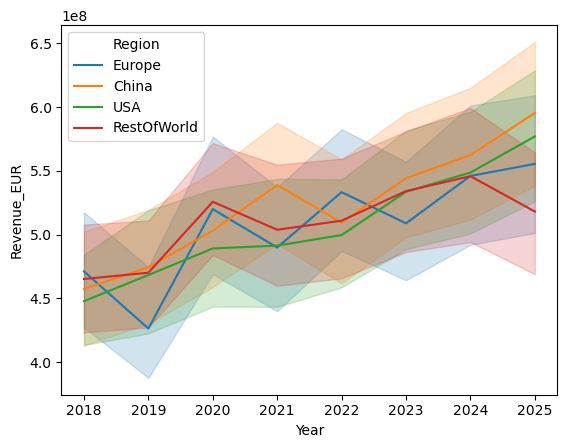

In [3]:
sns.lineplot(x="Year",y="Revenue_EUR",data=df,hue="Region")
plt.xlabel("Year")
plt.ylabel("Revenue_EUR")
plt.show()

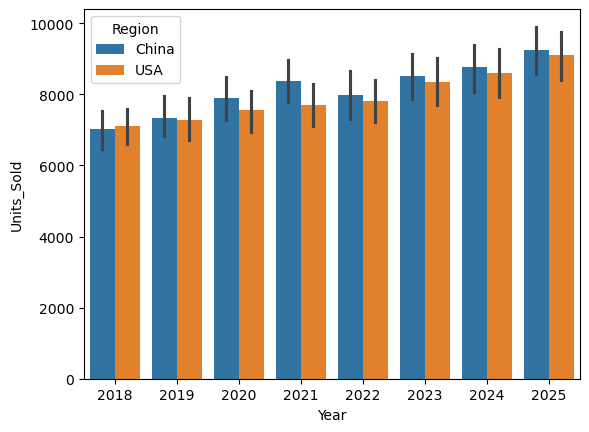

In [4]:
dft= df[(df["Region"] == "USA") | (df["Region"]=="China")]
sns.barplot(x="Year",y="Units_Sold",hue="Region",data=dft)
plt.xlabel("Year")
plt.ylabel("Units_Sold")
plt.show()

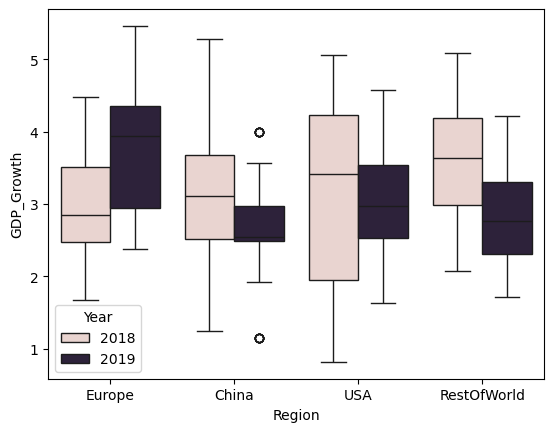

In [5]:
dft=df[(df["Year"]==2018) | (df["Year"]==2019)]
sns.boxplot(x="Region",y="GDP_Growth",data=dft,hue="Year")
plt.xlabel("Region")
plt.ylabel("GDP_Growth")
plt.show()

<Axes: xlabel='Fuel_Price_Index', ylabel='Count'>

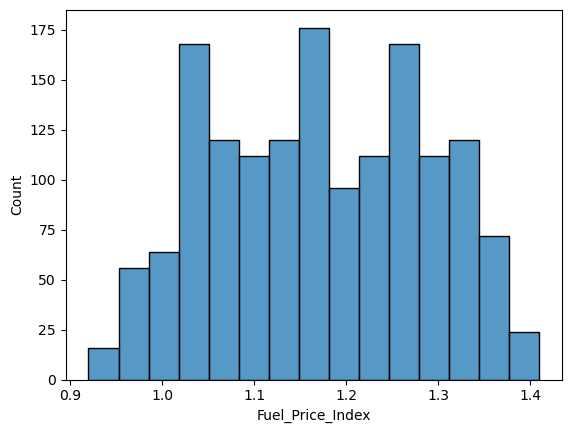

In [150]:
sns.histplot(x="Fuel_Price_Index",data=dft)

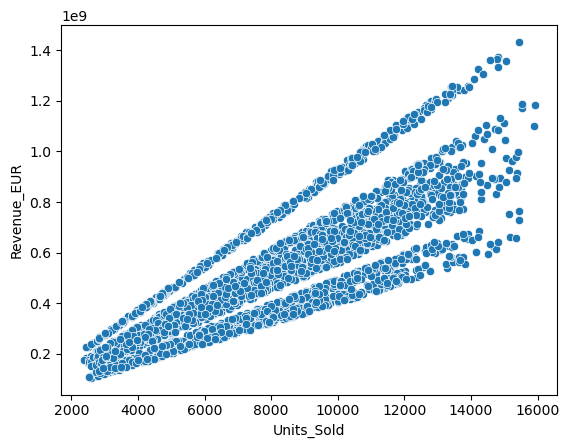

In [151]:
sns.scatterplot(x="Units_Sold",y="Revenue_EUR",data=df)
plt.xlabel("Units_Sold")
plt.ylabel("Revenue_EUR")
plt.show()

In [115]:
#for line chart
dfs = df[df["Region"].isin(["USA", "China"])].groupby("Year")["Revenue_EUR"].mean()
# for bar chart
dft = df.set_index("Model").loc[["X3","X5","X7"], ["Units_Sold"]]
dfl=dft.groupby("Model")["Units_Sold"].mean()
# for pie chart
dfn=df.groupby(["Region"])["GDP_Growth"].mean()
# for scatter plot
dfh=df[df["Model"].isin(["X3","X5"])].groupby("Units_Sold")["Revenue_EUR"].mean()    

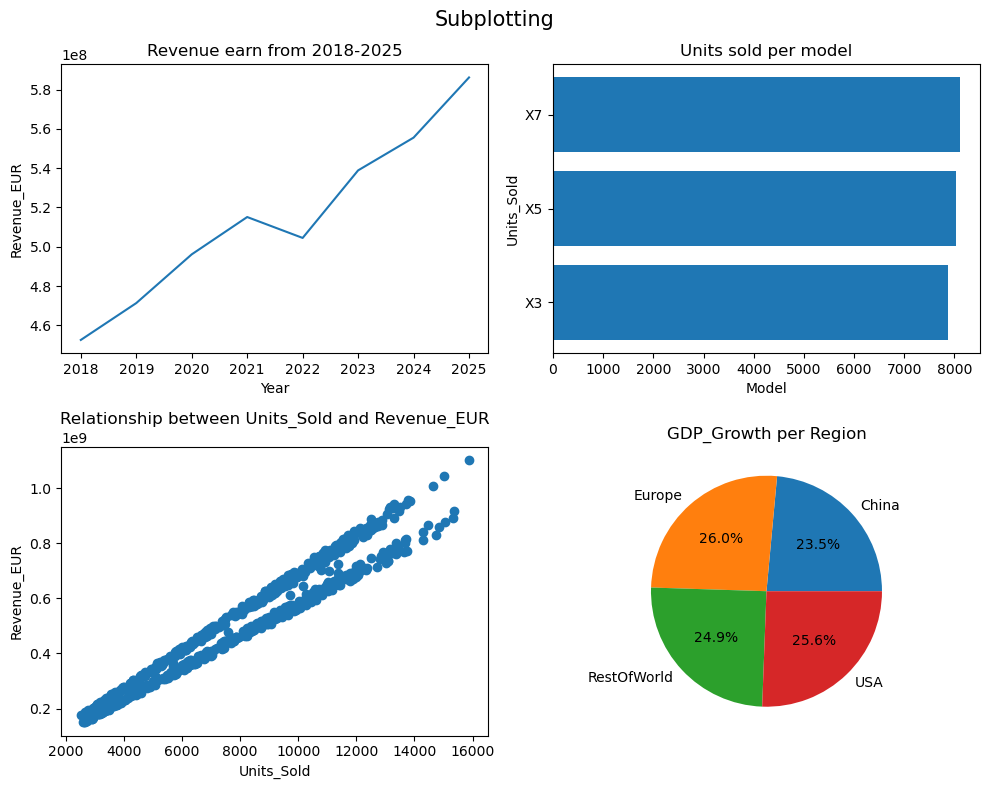

In [121]:
fig=plt.figure(figsize=(10,8))
# line chart
axs1=fig.add_subplot(2,2,1)
axs1.plot(dfs)
axs1.set_xlabel("Year")
axs1.set_ylabel("Revenue_EUR")
axs1.set_title("Revenue earn from 2018-2025")
# bar chart
axs2=fig.add_subplot(2,2,2)
axs2.barh(dfl.index,dfl)
axs2.set_xlabel("Model")
axs2.set_ylabel("Units_Sold")
axs2.set_title("Units sold per model")
# scatter plot
axs3=fig.add_subplot(2,2,3)
axs3.scatter(dfh.index,dfh)
axs3.set_xlabel("Units_Sold")
axs3.set_ylabel("Revenue_EUR")
axs3.set_title("Relationship between Units_Sold and Revenue_EUR")
# pie chart
axs4=fig.add_subplot(2,2,4)
axs4.pie(dfn,labels=dfn.index,autopct="%1.1f%%")
axs4.set_title("GDP_Growth per Region")
fig.suptitle("Subplotting",fontsize=15)
fig.tight_layout()
plt.show()